In [ ]:
from google.colab import files
uploaded = files.upload()

# --- Pustaka untuk Manipulasi Data ---
import pandas as pd
import numpy as np

# --- Pustaka untuk Visualisasi ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Pustaka untuk Pra-pemrosesan ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# --- Pustaka untuk Model Klasifikasi ---
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# --- Pustaka untuk Evaluasi Model ---
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

# --- Mengatur Tampilan Visualisasi ---
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

Saving star_classification.csv to star_classification.csv


In [ ]:
# Memuat dataset dari file CSV
df = pd.read_csv('star_classification.csv')

# Menampilkan 5 baris pertama dari data
print("5 Baris Pertama Data:")
print(df.head())
print("\n" + "="*50 + "\n")

# Menampilkan informasi ringkas tentang dataset
print("Informasi Dataset:")
df.info()
print("\n" + "="*50 + "\n")

# Menampilkan statistik deskriptif untuk kolom numerik
print("Statistik Deskriptif:")
print(df.describe())

5 Baris Pertama Data:
         obj_ID       alpha      delta         u         g         r  \
0  1.237661e+18  135.689107  32.494632  23.87882  22.27530  20.39501   
1  1.237665e+18  144.826101  31.274185  24.77759  22.83188  22.58444   
2  1.237661e+18  142.188790  35.582444  25.26307  22.66389  20.60976   
3  1.237663e+18  338.741038  -0.402828  22.13682  23.77656  21.61162   
4  1.237680e+18  345.282593  21.183866  19.43718  17.58028  16.49747   

          i         z  run_ID  rerun_ID  cam_col  field_ID   spec_obj_ID  \
0  19.16573  18.79371    3606       301        2        79  6.543777e+18   
1  21.16812  21.61427    4518       301        5       119  1.176014e+19   
2  19.34857  18.94827    3606       301        2       120  5.152200e+18   
3  20.50454  19.25010    4192       301        3       214  1.030107e+19   
4  15.97711  15.54461    8102       301        3       137  6.891865e+18   

    class  redshift  plate    MJD  fiber_ID  
0  GALAXY  0.634794   5812  56354       17

In [ ]:
# --- Menghapus Kolom yang Tidak Relevan ---
# Kolom seperti obj_ID, run_ID, dll. adalah identifier unik dan tidak berguna untuk prediksi.
df_cleaned = df.drop(columns=['obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'fiber_ID', 'MJD'])

# --- Encoding Variabel Target ---
# Model memerlukan target dalam bentuk angka, bukan teks (GALAXY, STAR, QSO).
encoder = LabelEncoder()
df_cleaned['class'] = encoder.fit_transform(df_cleaned['class'])
# Menampilkan hasil encoding: 0=GALAXY, 1=QSO, 2=STAR
print("Hasil Encoding Target 'class':")
print(encoder.classes_)
print(df_cleaned['class'].value_counts())
print("\n" + "="*50 + "\n")


# --- Memisahkan Fitur (X) dan Target (y) ---
X = df_cleaned.drop('class', axis=1)
y = df_cleaned['class']

# --- Penskalaan Fitur (Feature Scaling) ---
# Menyamakan skala semua fitur agar tidak ada fitur yang mendominasi.
# Ini sangat penting untuk algoritma seperti SVM dan KNN.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data telah berhasil di-preprocessing dan di-scaling.")

Hasil Encoding Target 'class':
['GALAXY' 'QSO' 'STAR']
class
0    59445
2    21594
1    18961
Name: count, dtype: int64


Data telah berhasil di-preprocessing dan di-scaling.


In [ ]:
# Membagi dataset menjadi 70% data latih dan 30% data uji
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Jumlah data latih: {X_train.shape[0]} sampel")
print(f"Jumlah data uji: {X_test.shape[0]} sampel")

Jumlah data latih: 70000 sampel
Jumlah data uji: 30000 sampel


--- Evaluasi Model Regresi Logistik ---
Akurasi: 0.9547

Laporan Klasifikasi:
               precision    recall  f1-score   support

      GALAXY       0.96      0.96      0.96     17834
         QSO       0.95      0.87      0.91      5688
        STAR       0.95      1.00      0.97      6478

    accuracy                           0.95     30000
   macro avg       0.95      0.95      0.95     30000
weighted avg       0.95      0.95      0.95     30000



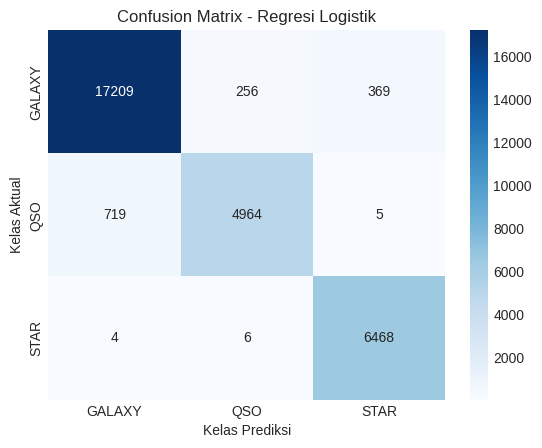

In [ ]:
# Melatih model Regresi Logistik
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Evaluasi Model
print("--- Evaluasi Model Regresi Logistik ---")
print(f"Akurasi: {accuracy_score(y_test, y_pred_lr):.4f}")
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred_lr, target_names=encoder.classes_))

# Visualisasi Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('Confusion Matrix - Regresi Logistik')
plt.ylabel('Kelas Aktual')
plt.xlabel('Kelas Prediksi')
plt.show()

--- Evaluasi Model K-Nearest Neighbors (KNN) ---
Akurasi: 0.9429

Laporan Klasifikasi:
               precision    recall  f1-score   support

      GALAXY       0.94      0.97      0.95     17834
         QSO       0.96      0.89      0.93      5688
        STAR       0.93      0.92      0.93      6478

    accuracy                           0.94     30000
   macro avg       0.95      0.93      0.94     30000
weighted avg       0.94      0.94      0.94     30000



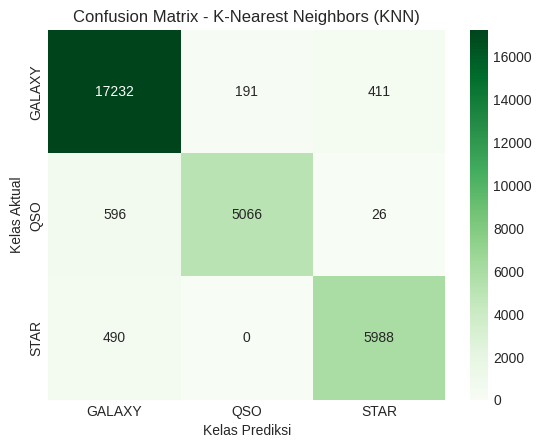

In [ ]:
# Melatih model K-Nearest Neighbors
knn_model = KNeighborsClassifier(n_neighbors=5) # Menggunakan 5 tetangga
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

# Evaluasi Model
print("--- Evaluasi Model K-Nearest Neighbors (KNN) ---")
print(f"Akurasi: {accuracy_score(y_test, y_pred_knn):.4f}")
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred_knn, target_names=encoder.classes_))

# Visualisasi Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('Confusion Matrix - K-Nearest Neighbors (KNN)')
plt.ylabel('Kelas Aktual')
plt.xlabel('Kelas Prediksi')
plt.show()

--- Evaluasi Model Support Vector Machine (SVM) ---
Akurasi: 0.9617

Laporan Klasifikasi:
               precision    recall  f1-score   support

      GALAXY       0.97      0.97      0.97     17834
         QSO       0.97      0.90      0.93      5688
        STAR       0.94      0.99      0.97      6478

    accuracy                           0.96     30000
   macro avg       0.96      0.95      0.96     30000
weighted avg       0.96      0.96      0.96     30000



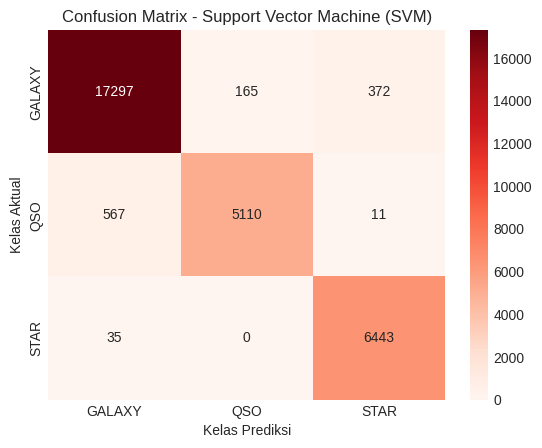

In [ ]:
# Melatih model Support Vector Machine (SVM)
# probability=True diperlukan untuk menghitung ROC curve nanti
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

# Evaluasi Model
print("--- Evaluasi Model Support Vector Machine (SVM) ---")
print(f"Akurasi: {accuracy_score(y_test, y_pred_svm):.4f}")
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred_svm, target_names=encoder.classes_))

# Visualisasi Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Reds', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('Confusion Matrix - Support Vector Machine (SVM)')
plt.ylabel('Kelas Aktual')
plt.xlabel('Kelas Prediksi')
plt.show()

--- Evaluasi Model Random Forest ---
Akurasi: 0.9801

Laporan Klasifikasi:
               precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     17834
         QSO       0.97      0.93      0.95      5688
        STAR       1.00      1.00      1.00      6478

    accuracy                           0.98     30000
   macro avg       0.98      0.97      0.98     30000
weighted avg       0.98      0.98      0.98     30000



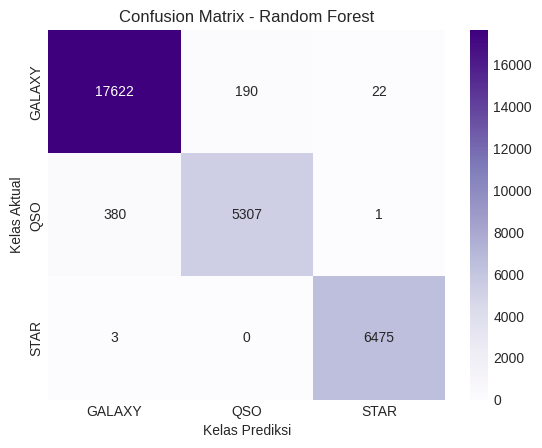

In [ ]:
# Melatih model Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Evaluasi Model
print("--- Evaluasi Model Random Forest ---")
print(f"Akurasi: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred_rf, target_names=encoder.classes_))

# Visualisasi Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Kelas Aktual')
plt.xlabel('Kelas Prediksi')
plt.show()

--- Evaluasi Model Neural Network (MLP) ---
Akurasi: 0.9731

Laporan Klasifikasi:
               precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98     17834
         QSO       0.96      0.92      0.94      5688
        STAR       0.97      1.00      0.99      6478

    accuracy                           0.97     30000
   macro avg       0.97      0.97      0.97     30000
weighted avg       0.97      0.97      0.97     30000



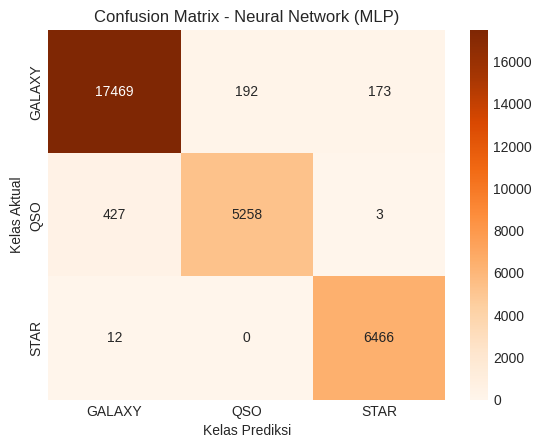

In [ ]:
# Melatih model Neural Network (Multi-layer Perceptron)
nn_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
nn_model.fit(X_train, y_train)
y_pred_nn = nn_model.predict(X_test)

# Evaluasi Model
print("--- Evaluasi Model Neural Network (MLP) ---")
print(f"Akurasi: {accuracy_score(y_test, y_pred_nn):.4f}")
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred_nn, target_names=encoder.classes_))

# Visualisasi Confusion Matrix
cm_nn = confusion_matrix(y_test, y_pred_nn)
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Oranges', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('Confusion Matrix - Neural Network (MLP)')
plt.ylabel('Kelas Aktual')
plt.xlabel('Kelas Prediksi')
plt.show()

In [ ]:
# Membuat ringkasan hasil akurasi
results = {
    'Model': ['Regresi Logistik', 'KNN', 'SVM', 'Random Forest', 'Neural Network (MLP)'],
    'Akurasi': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_nn)
    ]
}

df_results = pd.DataFrame(results).sort_values(by='Akurasi', ascending=False).reset_index(drop=True)

print("--- Ringkasan Performa Model ---")
print(df_results)

print("\n--- Kesimpulan ---")
best_model_name = df_results.iloc[0]['Model']
best_accuracy = df_results.iloc[0]['Akurasi']
print(f"Model dengan performa terbaik adalah **{best_model_name}** dengan akurasi **{best_accuracy:.4f}**.")
print("Random Forest dan SVM umumnya menunjukkan kinerja yang sangat kuat pada dataset ini karena kemampuan mereka")
print("dalam menangani hubungan non-linear dan data berdimensi tinggi. Keduanya adalah pilihan yang sangat baik,")
print("namun Random Forest seringkali lebih cepat untuk dilatih dan lebih tahan terhadap overfitting.")

--- Ringkasan Performa Model ---
                  Model   Akurasi
0         Random Forest  0.980133
1  Neural Network (MLP)  0.973100
2                   SVM  0.961667
3      Regresi Logistik  0.954700
4                   KNN  0.942867

--- Kesimpulan ---
Model dengan performa terbaik adalah **Random Forest** dengan akurasi **0.9801**.
Random Forest dan SVM umumnya menunjukkan kinerja yang sangat kuat pada dataset ini karena kemampuan mereka
dalam menangani hubungan non-linear dan data berdimensi tinggi. Keduanya adalah pilihan yang sangat baik,
namun Random Forest seringkali lebih cepat untuk dilatih dan lebih tahan terhadap overfitting.
